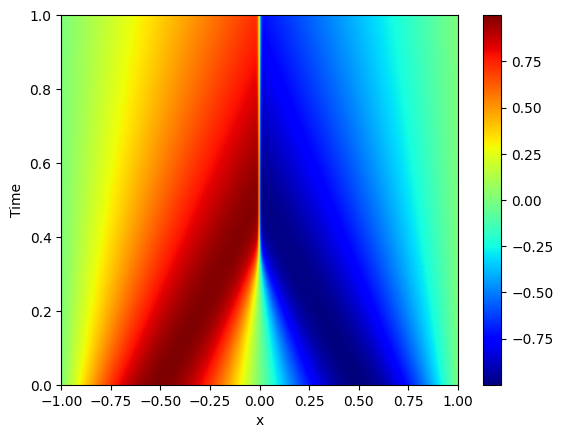

In [3]:
from math import pi

from pde import (
    CartesianGrid,
    MemoryStorage,
    PDEBase,
    ScalarField,
    plot_kymograph,
)


class BurgersPDE(PDEBase):
    """1D viscous Burgers equation."""

    def __init__(self, nu=0.01/pi):
        self.nu = nu  # viscosity

    def evolution_rate(self, state, t=0):
        """Time derivative ∂u/∂t."""
        assert state.grid.dim == 1  # ensure 1D

        # first spatial derivative u_x
        u_x = state.gradient("auto_periodic_neumann")[0]

        # second spatial derivative u_xx
        u_xx = state.laplace("auto_periodic_neumann")

        # Burgers equation
        return -state * u_x + self.nu * u_xx


# -----------------------------
# Set up spatial domain
# -----------------------------
grid = CartesianGrid([[-1, 1]], [400], periodic=True)

# Initial condition
state = ScalarField.from_expression(
    grid, "-sin(pi * x)"
)

# -----------------------------
# Solve and store the solution
# -----------------------------
storage = MemoryStorage()
eq = BurgersPDE()

eq.solve(
    state,
    t_range=1,
    solver="scipy",
    tracker=storage.tracker(0.005),
)

# -----------------------------
# Space–time visualization
# -----------------------------
plot_kymograph(storage, cmap="jet")


import numpy as np

# -----------------------------
# Extract as 1D numpy arrays
# -----------------------------
# Get 1D arrays for time t and space x
t_vals = np.array(storage.times)
x_vals = grid.axes_coords[0]

# Create a 2D meshgrid (shape: [len(t_vals), len(x_vals)])
X, T = np.meshgrid(x_vals, t_vals)

# Extract and flatten the spatial and time dimensions
x_1d = X.flatten()
t_1d = T.flatten()

# Extract and flatten the solution data corresponding to (x, t)
u_1d = np.array(storage.data).flatten()

np.column_stack((x_1d, t_1d, u_1d))  # shape: [len(t_vals)*len(x_vals), 3]
np.savetxt("burgers_solution.txt", np.column_stack((x_1d, t_1d, u_1d)))